# Task 5: Domestic vs. International Bias — Option B with Final Task 4 Blend

This notebook continues the Task 5 ethics analysis for the Expedia ranking model.

Bias investigated: **quality-of-service disparity between domestic and international searches**.

Mitigation tested here: **post-processing score blending**.

Important update compared with the previous Task 5 notebook:
- The baseline model is now the **final Task 4 blended model**, not an older single global ranker.
- The notebook trains the same Task 4 blend models on the training fold, predicts on the validation fold, and uses these blended validation scores as the original model output.
- Then it trains an international-specialist LightGBM Ranker and tests whether blending this specialist into international searches can reduce the domestic/international performance gap.

For domestic validation searches, the final Task 4 blend score is kept unchanged.
For international validation searches, the final score is:

\[
\text{final score} = (1 - \alpha) \cdot \text{Task 4 blend score} + \alpha \cdot \text{international specialist score}
\]

We tune `alpha` on the validation fold and compare:
1. the original final Task 4 blend,
2. full specialist replacement for international searches,
3. the recommended blended post-processing mitigation.


In [1]:
# ---------------------------------------------------
# Cell 1: Imports and settings
# ---------------------------------------------------

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

RANDOM_STATE = 42
K = 5

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("Imports loaded.")

Imports loaded.


In [2]:
# ---------------------------------------------------
# Cell 2: Load prepared Task 3 feature files
# ---------------------------------------------------
# These files should already exist from your Task 3 notebook.

train_feat = pd.read_parquet("data/train_features.parquet")
val_feat = pd.read_parquet("data/val_features.parquet")

print("Train features shape:", train_feat.shape)
print("Validation features shape:", val_feat.shape)

display(train_feat.head())

Train features shape: (3980039, 277)
Validation features shape: (978308, 277)


,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,promotion_flag,srch_destination_id,srch_length_of_stay,srch_booking_window,srch_adults_count,srch_children_count,srch_room_count,srch_saturday_night_bool,srch_query_affinity_score,orig_destination_distance,random_bool,comp1_rate,comp1_inv,comp1_rate_percent_diff,comp2_rate,comp2_inv,comp2_rate_percent_diff,comp3_rate,comp3_inv,comp3_rate_percent_diff,comp4_rate,comp4_inv,comp4_rate_percent_diff,comp5_rate,comp5_inv,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool,relevance,visitor_hist_starrating_missing,visitor_hist_adr_usd_missing,srch_query_affinity_score_missing,orig_destination_distance_missing,prop_location_score2_missing,prop_review_score_missing,prop_review_score_is_zero,prop_starrating_is_zero,price_is_zero,price_below_1,price_below_10,price_usd_capped,price_usd_clipped,log_price_usd,log_price_usd_capped,log_price_usd_clipped,log_orig_destination_distance,total_guests,children_present,multi_room,domestic_search,log_booking_window,log_length_of_stay,last_minute_booking,long_booking_window,long_stay,is_4_star,is_5_star,high_review_score,search_month,search_quarter,search_dayofweek,search_hour,search_is_weekend,comp_rate_missing_count,comp_inv_missing_count,comp_pct_missing_count,comp_has_any_rate_data,comp_has_any_inv_data,comp_has_any_pct_data,comp_expedia_cheaper_count,comp_expedia_more_expensive_count,comp_same_price_count,comp_unavailable_count,comp_available_count,...,star_value_rank,location2_value_rank,children_x_price_ratio,children_x_review,multiroom_x_price_ratio,multiroom_x_review,prop_id_count,prop_id_mean_price,prop_id_median_price,prop_id_std_price,prop_id_min_price,prop_id_max_price,prop_id_mean_log_price,prop_id_median_log_price,prop_id_std_log_price,prop_id_mean_starrating,prop_id_std_starrating,prop_id_mean_review_score,prop_id_std_review_score,prop_id_mean_location_score1,prop_id_std_location_score1,prop_id_mean_location_score2,prop_id_std_location_score2,prop_id_mean_promotion_flag,prop_id_mean_brand_bool,prop_id_mean_booking_window,prop_id_mean_length_of_stay,prop_id_mean_total_guests,prop_id_mean_domestic_search,prop_id_mean_query_affinity,prop_id_mean_orig_distance,prop_id_mean_comp_cheaper,prop_id_mean_comp_more_expensive,prop_id_mean_comp_same_price,prop_id_mean_comp_unavailable,prop_id_mean_comp_available,prop_id_mean_comp_rate_missing,prop_id_mean_comp_inv_missing,prop_id_mean_random_bool,dest_id_count,dest_id_mean_price,dest_id_median_price,dest_id_std_price,dest_id_mean_log_price,dest_id_mean_starrating,dest_id_mean_review_score,dest_id_mean_location_score1,dest_id_mean_location_score2,dest_id_mean_promotion_flag,dest_id_mean_brand_bool,dest_id_mean_booking_window,dest_id_mean_length_of_stay,dest_id_mean_total_guests,dest_id_mean_domestic_search,prop_dest_count,prop_dest_mean_price,prop_dest_median_price,prop_dest_mean_log_price,prop_dest_mean_starrating,prop_dest_mean_review_score,prop_dest_mean_location2,prop_dest_mean_promotion,price_diff_from_prop_median,price_ratio_to_prop_median,log_price_diff_from_prop_mean,star_diff_from_prop_mean,review_diff_from_prop_mean,location1_diff_from_prop_mean,location2_diff_from_prop_mean,promotion_diff_from_prop_mean,price_diff_from_dest_median,price_ratio_to_dest_median,star_diff_from_dest_mean,review_diff_from_dest_mean,location2_diff_from_dest_mean,prop_id_te_count,prop_id_te_click_rate,prop_id_te_booking_rate,prop_id_te_relevance_mean,prop_id_te_log_count,dest_id_te_count,dest_id_te_click_rate,dest_id_te_booking_rate,dest_id_te_relevance_mean,dest_id_te_log_count,prop_dest_te_count,prop_dest_te_click_rate,prop_dest_te_booking_rate,prop_dest_te_r

In [3]:
# ---------------------------------------------------
# Cell 3: Define domestic vs. international search groups
# ---------------------------------------------------
# domestic_search = 1 means visitor country equals hotel country.
# domestic_search = 0 means international / non-domestic search.

for df in [train_feat, val_feat]:
    df["domestic_search"] = (
        df["visitor_location_country_id"] == df["prop_country_id"]
    ).astype(np.int8)

print("Train domestic share:")
display(train_feat["domestic_search"].value_counts(normalize=True).rename(index={1: "Domestic", 0: "International"}))

print("Validation domestic share:")
display(val_feat["domestic_search"].value_counts(normalize=True).rename(index={1: "Domestic", 0: "International"}))

Train domestic share:


domestic_search
Domestic         0.63614
International    0.36386
Name: proportion, dtype: float64

Validation domestic share:


domestic_search
Domestic         0.646173
International    0.353827
Name: proportion, dtype: float64

In [4]:
# ---------------------------------------------------
# Cell 4: Basic group description on validation set
# ---------------------------------------------------

def describe_domestic_groups(df):
    rows = []
    for value, name in [(1, "Domestic searches"), (0, "International searches")]:
        g = df[df["domestic_search"] == value]
        rows.append({
            "domestic_group": name,
            "rows": len(g),
            "searches": g["srch_id"].nunique(),
            "click_rate": g["click_bool"].mean(),
            "booking_rate": g["booking_bool"].mean(),
            "mean_relevance": g["relevance"].mean(),
            "mean_price": g["price_usd"].mean(),
            "mean_distance": g["orig_destination_distance"].replace(-1, np.nan).mean()
        })
    return pd.DataFrame(rows)

group_description = describe_domestic_groups(val_feat)
display(group_description)

,domestic_group,rows,searches,click_rate,booking_rate,mean_relevance,mean_price,mean_distance
0,Domestic searches,632156,25781,0.044557,0.029085,0.160895,252.778940,504.180998
1,International searches,346152,14284,0.046251,0.027693,0.157024,540.085716,1853.067926


In [5]:
# ---------------------------------------------------
# Cell 5: Build feature list
# ---------------------------------------------------
# We do not use target-related columns or identifiers as model inputs.
# domestic_search is allowed as a feature because it can be computed in the test set.

NON_FEATURE_COLS = [
    "srch_id",
    "prop_id",
    "date_time",
    "click_bool",
    "booking_bool",
    "gross_bookings_usd",
    "position",
    "relevance"
]

feature_cols = [
    col for col in train_feat.columns
    if col not in NON_FEATURE_COLS
    and pd.api.types.is_numeric_dtype(train_feat[col])
]

missing_in_val = set(feature_cols) - set(val_feat.columns)
extra_in_val = set(val_feat.columns) - set(train_feat.columns)

print("Number of model features:", len(feature_cols))
print("Missing in validation:", missing_in_val)
print("Extra columns in validation compared with train:", len(extra_in_val))
print("First 40 features:")
print(feature_cols[:40])

Number of model features: 269
Missing in validation: set()
Extra columns in validation compared with train: 0
First 40 features:
['site_id', 'visitor_location_country_id', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'price_usd', 'promotion_flag', 'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool', 'srch_query_affinity_score', 'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv', 'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv', 'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv', 'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv', 'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv', 'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv']


In [6]:
# ---------------------------------------------------
# Cell 6: Sort by search ID and build global matrices
# ---------------------------------------------------
# LightGBM Ranker requires rows to be sorted by group, with group sizes matching row order.

train_feat = train_feat.sort_values("srch_id").reset_index(drop=True)
val_feat = val_feat.sort_values("srch_id").reset_index(drop=True)

# Keep a row id for safe score replacement/blending later.
val_feat["row_id"] = np.arange(len(val_feat))

X_train = train_feat[feature_cols]
y_train = train_feat["relevance"].astype(int)
group_train = train_feat.groupby("srch_id").size().to_numpy()

X_val = val_feat[feature_cols]
y_val = val_feat["relevance"].astype(int)
group_val = val_feat.groupby("srch_id").size().to_numpy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Number of train search groups:", len(group_train))
print("Number of validation search groups:", len(group_val))

X_train: (3980039, 269)
X_val: (978308, 269)
Number of train search groups: 159836
Number of validation search groups: 39959


In [7]:
# ---------------------------------------------------
# Cell 7: Evaluation functions
# ---------------------------------------------------

def dcg_at_k(relevances, k=5):
    relevances = np.asarray(relevances)[:k]
    if len(relevances) == 0:
        return 0.0
    discounts = np.log2(np.arange(2, len(relevances) + 2))
    gains = (2 ** relevances - 1)
    return np.sum(gains / discounts)


def ndcg_at_k_for_group(y_true, y_score, k=5):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(-y_score)
    ranked_relevance = y_true[order]
    ideal_order = np.argsort(-y_true)
    ideal_relevance = y_true[ideal_order]
    dcg = dcg_at_k(ranked_relevance, k=k)
    idcg = dcg_at_k(ideal_relevance, k=k)
    if idcg == 0:
        return 0.0
    return dcg / idcg


def evaluate_domestic_international_bias(df, scores, model_name, k=5):
    """
    Evaluates ranking quality for domestic vs. international validation searches.

    Metrics:
    - mean NDCG@5 per group
    - booked Recall@5 per group
    - top-1 booked hit rate per group
    - mean rank of booked hotel per group
    """
    tmp = df[[
        "srch_id", "prop_id", "relevance", "booking_bool", "domestic_search"
    ]].copy()
    tmp["score"] = scores

    per_search_rows = []

    for srch_id, g in tmp.groupby("srch_id", sort=False):
        group_value = int(g["domestic_search"].iloc[0])
        y_true = g["relevance"].to_numpy()
        y_score = g["score"].to_numpy()
        ndcg = ndcg_at_k_for_group(y_true, y_score, k=k)

        ranked = g.sort_values("score", ascending=False).reset_index(drop=True)
        booked_positions = np.where(ranked["booking_bool"].to_numpy() == 1)[0]

        has_booking = len(booked_positions) > 0
        if has_booking:
            booked_rank = int(booked_positions[0]) + 1
            booked_in_topk = booked_rank <= k
            booked_at_top1 = booked_rank == 1
        else:
            booked_rank = np.nan
            booked_in_topk = np.nan
            booked_at_top1 = np.nan

        per_search_rows.append({
            "srch_id": srch_id,
            "domestic_search": group_value,
            "ndcg_at_5": ndcg,
            "has_booking": has_booking,
            "booked_rank": booked_rank,
            "booked_in_top5": booked_in_topk,
            "booked_at_top1": booked_at_top1
        })

    per_search = pd.DataFrame(per_search_rows)

    group_results = []
    for value, name in [(1, "Domestic searches"), (0, "International searches")]:
        g = per_search[per_search["domestic_search"] == value]
        g_booked = g[g["has_booking"]]

        group_results.append({
            "group": name,
            "num_searches": len(g),
            "num_booked_searches": len(g_booked),
            "mean_ndcg_at_5": g["ndcg_at_5"].mean(),
            "booked_recall_at_5": g_booked["booked_in_top5"].mean(),
            "booked_top1_hit_rate": g_booked["booked_at_top1"].mean(),
            "mean_booked_rank": g_booked["booked_rank"].mean()
        })

    group_results = pd.DataFrame(group_results)

    domestic = group_results[group_results["group"] == "Domestic searches"].iloc[0]
    international = group_results[group_results["group"] == "International searches"].iloc[0]

    metrics = {
        "model": model_name,
        "overall_ndcg@5": per_search["ndcg_at_5"].mean(),
        "domestic_ndcg@5": domestic["mean_ndcg_at_5"],
        "international_ndcg@5": international["mean_ndcg_at_5"],
        "international_minus_domestic_ndcg@5": international["mean_ndcg_at_5"] - domestic["mean_ndcg_at_5"],
        "domestic_booked_recall@5": domestic["booked_recall_at_5"],
        "international_booked_recall@5": international["booked_recall_at_5"],
        "international_minus_domestic_recall@5": international["booked_recall_at_5"] - domestic["booked_recall_at_5"],
        "domestic_top1_hit_rate": domestic["booked_top1_hit_rate"],
        "international_top1_hit_rate": international["booked_top1_hit_rate"],
        "domestic_mean_booked_rank": domestic["mean_booked_rank"],
        "international_mean_booked_rank": international["mean_booked_rank"],
        "num_domestic_searches": domestic["num_searches"],
        "num_international_searches": international["num_searches"],
        "num_domestic_booked_searches": domestic["num_booked_searches"],
        "num_international_booked_searches": international["num_booked_searches"]
    }

    return group_results, metrics, per_search

In [8]:
# ---------------------------------------------------
# Cell 8: Final Task 4 blend settings
# ---------------------------------------------------
# Option B: use the actual final Task 4 blended ranker as the Task 5 baseline.
# These are the te_alpha=100 blend models you selected after Task 4 tuning.
# The validation baseline score is the weighted average of these model predictions.

final_blend_model_params = {
    "A_new_best": {
        "num_leaves": 639,
        "learning_rate": 0.015,
        "min_child_samples": 1500,
        "reg_lambda": 120.0,
        "reg_alpha": 0.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "n_estimators": 541
    },
    "B_old_best": {
        "num_leaves": 639,
        "learning_rate": 0.02,
        "min_child_samples": 1500,
        "reg_lambda": 80.0,
        "reg_alpha": 0.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "n_estimators": 316
    }
}

# This was the selected Task 4 blend used for the final model.
final_blend_weights = {
    "A_new_best": 0.5,
    "B_old_best": 0.5
}

# For the international-specialist mitigation, use the strongest single-model
# configuration as the starting point. Early stopping in Cell 12 will choose the
# number of trees for the international-only model.
specialist_parameters = {
    "num_leaves": 639,
    "learning_rate": 0.015,
    "min_child_samples": 1500,
    "reg_lambda": 120.0,
    "reg_alpha": 0.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_estimators": 1000
}

print("Final Task 4 blend models:")
for model_name, params in final_blend_model_params.items():
    print(model_name, params, "weight=", final_blend_weights[model_name])

print("\nInternational-specialist parameters:")
print(specialist_parameters)


Final Task 4 blend models:
A_new_best {'num_leaves': 639, 'learning_rate': 0.015, 'min_child_samples': 1500, 'reg_lambda': 120.0, 'reg_alpha': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_estimators': 541} weight= 0.5
B_old_best {'num_leaves': 639, 'learning_rate': 0.02, 'min_child_samples': 1500, 'reg_lambda': 80.0, 'reg_alpha': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_estimators': 316} weight= 0.5

International-specialist parameters:
{'num_leaves': 639, 'learning_rate': 0.015, 'min_child_samples': 1500, 'reg_lambda': 120.0, 'reg_alpha': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_estimators': 1000}


In [9]:
# ---------------------------------------------------
# Cell 9: Recreate final Task 4 blended validation scores
# ---------------------------------------------------
# This replaces the old single global model baseline.
# We train each selected Task 4 blend model on the training fold and average
# their validation predictions using final_blend_weights.

final_blend_models = {}
final_blend_component_scores = {}

global_scores = np.zeros(X_val.shape[0], dtype=np.float64)

for model_name, params in final_blend_model_params.items():
    weight = final_blend_weights[model_name]

    print("=" * 60)
    print("Training final Task 4 blend component:", model_name)
    print("Weight:", weight)
    print(params)

    ranker = lgb.LGBMRanker(
        objective="lambdarank",
        metric="ndcg",
        ndcg_eval_at=[5],
        boosting_type="gbdt",

        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        num_leaves=params["num_leaves"],
        max_depth=-1,
        min_child_samples=params["min_child_samples"],

        reg_lambda=params["reg_lambda"],
        reg_alpha=params["reg_alpha"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],

        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    ranker.fit(
        X_train,
        y_train,
        group=group_train
    )

    component_scores = ranker.predict(X_val)

    final_blend_models[model_name] = ranker
    final_blend_component_scores[model_name] = component_scores
    global_scores += weight * component_scores

print("Final Task 4 blended validation scores created.")


Training final Task 4 blend component: A_new_best
Weight: 0.5
{'num_leaves': 639, 'learning_rate': 0.015, 'min_child_samples': 1500, 'reg_lambda': 120.0, 'reg_alpha': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_estimators': 541}


/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.601312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 38286
[LightGBM] [Info] Number of data points in the train set: 3980039, number of used features: 262


/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Training final Task 4 blend component: B_old_best
Weight: 0.5
{'num_leaves': 639, 'learning_rate': 0.02, 'min_child_samples': 1500, 'reg_lambda': 80.0, 'reg_alpha': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_estimators': 316}


/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.653341 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 38286
[LightGBM] [Info] Number of data points in the train set: 3980039, number of used features: 262


/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Final Task 4 blended validation scores created.


In [10]:
# ---------------------------------------------------
# Cell 10: Evaluate original final Task 4 blend
# ---------------------------------------------------
# In the rest of this notebook, global_scores means the original final Task 4
# blended baseline. This keeps the old downstream code mostly unchanged.

global_group_results, global_metrics, global_per_search = evaluate_domestic_international_bias(
    val_feat,
    global_scores,
    model_name="Original final Task 4 blended LightGBM Ranker",
    k=K
)

display(global_group_results)
display(pd.DataFrame([global_metrics]).T.rename(columns={0: "value"}))


,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,25721,18381,0.415919,0.634079,0.245416,6.025298
1,International searches,14238,9591,0.396352,0.606610,0.233135,6.419873


,value
model,Original final Task 4 blended LightGBM Ranker
overall_ndcg@5,0.408947
domestic_ndcg@5,0.415919
international_ndcg@5,0.396352
international_minus_domestic_ndcg@5,-0.019567
domestic_booked_recall@5,0.634079
international_booked_recall@5,0.60661
international_minus_domestic_recall@5,-0.027468
domestic_top1_hit_rate,0.245416
international_top1_hit_rate,0.233135


In [11]:
# ---------------------------------------------------
# Cell 11: Prepare international-only training and validation data
# ---------------------------------------------------
# Specialist model: trained only on international / non-domestic searches.

train_int = train_feat[train_feat["domestic_search"] == 0].copy()
val_int = val_feat[val_feat["domestic_search"] == 0].copy()

train_int = train_int.sort_values("srch_id").reset_index(drop=True)
val_int = val_int.sort_values("srch_id").reset_index(drop=True)

X_train_int = train_int[feature_cols]
y_train_int = train_int["relevance"].astype(int)
group_train_int = train_int.groupby("srch_id").size().to_numpy()

X_val_int = val_int[feature_cols]
y_val_int = val_int["relevance"].astype(int)
group_val_int = val_int.groupby("srch_id").size().to_numpy()

print("International train rows:", X_train_int.shape)
print("International validation rows:", X_val_int.shape)
print("International train searches:", len(group_train_int))
print("International validation searches:", len(group_val_int))

International train rows: (1448177, 269)
International validation rows: (346152, 269)
International train searches: 59311
International validation searches: 14284


In [12]:
# ---------------------------------------------------
# Cell 12: Train international specialist ranker
# ---------------------------------------------------
# This mitigation model is trained only on international / non-domestic searches.
# It starts from the strongest single-model configuration, but uses early stopping
# because the international-only training set is smaller than the full training set.

international_ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_eval_at=[5],
    boosting_type="gbdt",

    n_estimators=specialist_parameters["n_estimators"],
    learning_rate=specialist_parameters["learning_rate"],
    num_leaves=specialist_parameters["num_leaves"],
    max_depth=-1,
    min_child_samples=specialist_parameters["min_child_samples"],

    reg_lambda=specialist_parameters["reg_lambda"],
    reg_alpha=specialist_parameters["reg_alpha"],
    subsample=specialist_parameters["subsample"],
    colsample_bytree=specialist_parameters["colsample_bytree"],

    random_state=RANDOM_STATE,
    n_jobs=-1
)

international_ranker.fit(
    X_train_int,
    y_train_int,
    group=group_train_int,
    eval_set=[(X_val_int, y_val_int)],
    eval_group=[group_val_int],
    eval_at=[5],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print("International specialist model trained.")
print("Best iteration:", international_ranker.best_iteration_)


/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.269665 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 38479
[LightGBM] [Info] Number of data points in the train set: 1448177, number of used features: 259
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [13]:
# ---------------------------------------------------
# Cell 13: Predict international-specialist scores for international validation rows
# ---------------------------------------------------
# These scores are aligned with val_int and with the international rows in val_feat via row_id.

international_specialist_scores = international_ranker.predict(
    X_val_int,
    num_iteration=international_ranker.best_iteration_
)

int_only_group_results, int_only_metrics, int_only_per_search = evaluate_domestic_international_bias(
    val_int,
    international_specialist_scores,
    model_name="International specialist only on international searches",
    k=K
)

display(int_only_group_results)
display(pd.DataFrame([int_only_metrics]).T.rename(columns={0: "value"}))

/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,0,0,NaN,NaN,NaN,NaN
1,International searches,14284,9586,0.389309,0.600042,0.226476,6.582099


,value
model,International specialist only on international...
overall_ndcg@5,0.389309
domestic_ndcg@5,NaN
international_ndcg@5,0.389309
international_minus_domestic_ndcg@5,NaN
domestic_booked_recall@5,NaN
international_booked_recall@5,0.600042
international_minus_domestic_recall@5,NaN
domestic_top1_hit_rate,NaN
international_top1_hit_rate,0.226476


In [14]:
# ---------------------------------------------------
# Cell 14: Full specialist replacement baseline
# ---------------------------------------------------
# This is the full group-specific replacement strategy:
# - domestic searches: keep final Task 4 blended score
# - international searches: replace with international-specialist score

replacement_scores = global_scores.copy()
international_row_ids = val_int["row_id"].to_numpy()
replacement_scores[international_row_ids] = international_specialist_scores

replacement_group_results, replacement_metrics, replacement_per_search = evaluate_domestic_international_bias(
    val_feat,
    replacement_scores,
    model_name="Full replacement: final blend domestic + international specialist",
    k=K
)

display(replacement_group_results)
display(pd.DataFrame([replacement_metrics]).T.rename(columns={0: "value"}))


,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,25721,18381,0.415976,0.634079,0.245471,6.026223
1,International searches,14238,9591,0.390387,0.599520,0.226567,6.593786


,value
model,Full replacement: final blend domestic + inter...
overall_ndcg@5,0.406858
domestic_ndcg@5,0.415976
international_ndcg@5,0.390387
international_minus_domestic_ndcg@5,-0.025589
domestic_booked_recall@5,0.634079
international_booked_recall@5,0.59952
international_minus_domestic_recall@5,-0.034558
domestic_top1_hit_rate,0.245471
international_top1_hit_rate,0.226567


In [15]:
# ---------------------------------------------------
# Cell 15: Post-processing mitigation by score blending
# ---------------------------------------------------
# For domestic searches, keep the final Task 4 blended score.
# For international searches, blend the final Task 4 blended score with the
# international-specialist score:
# final_score = (1 - alpha) * final_task4_blend_score + alpha * specialist_score
#
# alpha = 0.0 is the original final Task 4 blend.
# alpha = 1.0 is full specialist replacement for international searches.

blend_results = []
blend_scores_by_alpha = {}

alphas = np.round(np.arange(0.0, 1.01, 0.05), 2)

for alpha in alphas:
    blended_scores = global_scores.copy()

    blended_scores[international_row_ids] = (
        (1 - alpha) * global_scores[international_row_ids]
        + alpha * international_specialist_scores
    )

    _, metrics, _ = evaluate_domestic_international_bias(
        val_feat,
        blended_scores,
        model_name=f"Post-processing blend alpha={alpha:.2f}",
        k=K
    )

    metrics["alpha"] = alpha
    blend_results.append(metrics)
    blend_scores_by_alpha[alpha] = blended_scores

blend_results_df = pd.DataFrame(blend_results)

cols_first = [
    "alpha",
    "model",
    "overall_ndcg@5",
    "domestic_ndcg@5",
    "international_ndcg@5",
    "international_minus_domestic_ndcg@5",
    "domestic_booked_recall@5",
    "international_booked_recall@5",
    "international_minus_domestic_recall@5",
    "domestic_top1_hit_rate",
    "international_top1_hit_rate",
    "domestic_mean_booked_rank",
    "international_mean_booked_rank"
]

blend_results_df = blend_results_df[cols_first]

numeric_cols = blend_results_df.select_dtypes(include=["number"]).columns
blend_results_df[numeric_cols] = blend_results_df[numeric_cols].round(6)

display(blend_results_df)


,alpha,model,overall_ndcg@5,domestic_ndcg@5,international_ndcg@5,international_minus_domestic_ndcg@5,domestic_booked_recall@5,international_booked_recall@5,international_minus_domestic_recall@5,domestic_top1_hit_rate,international_top1_hit_rate,domestic_mean_booked_rank,international_mean_booked_rank
0,0.00,Post-processing blend alpha=0.00,0.408947,0.415919,0.396352,-0.019567,0.634079,0.606610,-0.027468,0.245416,0.233135,6.025298,6.419873
1,0.05,Post-processing blend alpha=0.05,0.408830,0.415919,0.396022,-0.019898,0.634079,0.606298,-0.027781,0.245416,0.232822,6.025298,6.417892
2,0.10,Post-processing blend alpha=0.10,0.408825,0.415919,0.396009,-0.019911,0.634079,0.606506,-0.027573,0.245416,0.232822,6.025352,6.418622
3,0.15,Post-processing blend alpha=0.15,0.408911,0.415921,0.396246,-0.019675,0.634079,0.607132,-0.026947,0.245416,0.232927,6.025298,6.419873
4,0.20,Post-processing blend alpha=0.20,0.408865,0.415936,0.396093,-0.019843,0.634079,0.607132,-0.026947,0.245416,0.233135,6.025298,6.419456
5,0.25,Post-processing blend alpha=0.25,0.408835,0.415936,0.396007,-0.019929,0.634079,0.607340,-0.026738,0.245416,0.232822,6.025407,6.419873
6,0.30,Post-processing blend alpha=0.30,0.408890,0.415938,0.396156,-0.019782,0.634079,0.607549,-0.026530,0.245416,0.232614,6.025461,6.420290
7,0.35,Post-processing blend alpha=0.35,0.408955,0.415938,0.396339,-0.019600,0.634079,0.607862,-0.026217,0.245416,0.233865,6.025515,6.419143
8,0.40,Post-processing blend alpha=0.40,0.408871,0.415938,0.396104,-0.019834,0.634079,0.606193,-0.027885,0.245416,0.233761,6.025624,6.423001
9,0.45,Post-processing blend alpha=0.45,0.409031,0.415943,0.396543,-0.019400,0.634079,0.606402,-0.027677,0.245416,0.234282,6.025570,6.424460


In [16]:
# ---------------------------------------------------
# Cell 16: Select useful blended models
# ---------------------------------------------------
# We inspect several possible selection criteria:
# 1. best overall NDCG@5
# 2. best international NDCG@5
# 3. smallest absolute NDCG gap
# 4. balanced choice: best international NDCG among models with overall NDCG >= original final Task 4 blend

original_overall = global_metrics["overall_ndcg@5"]

blend_selection_df = blend_results_df.copy()
blend_selection_df["abs_ndcg_gap"] = blend_selection_df["international_minus_domestic_ndcg@5"].abs()

best_overall_blend = blend_selection_df.sort_values("overall_ndcg@5", ascending=False).iloc[0]
best_international_blend = blend_selection_df.sort_values("international_ndcg@5", ascending=False).iloc[0]
best_gap_blend = blend_selection_df.sort_values("abs_ndcg_gap", ascending=True).iloc[0]

valid_balanced = blend_selection_df[blend_selection_df["overall_ndcg@5"] >= original_overall]
if len(valid_balanced) > 0:
    best_balanced_blend = valid_balanced.sort_values("international_ndcg@5", ascending=False).iloc[0]
else:
    # If no blended model preserves overall NDCG, fall back to best international NDCG.
    best_balanced_blend = best_international_blend

print("Original final Task 4 blend overall NDCG@5:", round(original_overall, 6))
print("Best overall blend:")
display(best_overall_blend)
print("Best international-NDCG blend:")
display(best_international_blend)
print("Smallest absolute NDCG-gap blend:")
display(best_gap_blend)
print("Recommended balanced blend:")
display(best_balanced_blend)

recommended_alpha = float(best_balanced_blend["alpha"])
print("Recommended alpha:", recommended_alpha)


Original final Task 4 blend overall NDCG@5: 0.408947
Best overall blend:


alpha                                                                0.45
model                                    Post-processing blend alpha=0.45
overall_ndcg@5                                                   0.409031
domestic_ndcg@5                                                  0.415943
international_ndcg@5                                             0.396543
international_minus_domestic_ndcg@5                               -0.0194
domestic_booked_recall@5                                         0.634079
international_booked_recall@5                                    0.606402
international_minus_domestic_recall@5                           -0.027677
domestic_top1_hit_rate                                           0.245416
international_top1_hit_rate                                      0.234282
domestic_mean_booked_rank                                         6.02557
international_mean_booked_rank                                    6.42446
abs_ndcg_gap                          

Best international-NDCG blend:


alpha                                                                0.45
model                                    Post-processing blend alpha=0.45
overall_ndcg@5                                                   0.409031
domestic_ndcg@5                                                  0.415943
international_ndcg@5                                             0.396543
international_minus_domestic_ndcg@5                               -0.0194
domestic_booked_recall@5                                         0.634079
international_booked_recall@5                                    0.606402
international_minus_domestic_recall@5                           -0.027677
domestic_top1_hit_rate                                           0.245416
international_top1_hit_rate                                      0.234282
domestic_mean_booked_rank                                         6.02557
international_mean_booked_rank                                    6.42446
abs_ndcg_gap                          

Smallest absolute NDCG-gap blend:


alpha                                                                0.45
model                                    Post-processing blend alpha=0.45
overall_ndcg@5                                                   0.409031
domestic_ndcg@5                                                  0.415943
international_ndcg@5                                             0.396543
international_minus_domestic_ndcg@5                               -0.0194
domestic_booked_recall@5                                         0.634079
international_booked_recall@5                                    0.606402
international_minus_domestic_recall@5                           -0.027677
domestic_top1_hit_rate                                           0.245416
international_top1_hit_rate                                      0.234282
domestic_mean_booked_rank                                         6.02557
international_mean_booked_rank                                    6.42446
abs_ndcg_gap                          

Recommended balanced blend:


alpha                                                                0.45
model                                    Post-processing blend alpha=0.45
overall_ndcg@5                                                   0.409031
domestic_ndcg@5                                                  0.415943
international_ndcg@5                                             0.396543
international_minus_domestic_ndcg@5                               -0.0194
domestic_booked_recall@5                                         0.634079
international_booked_recall@5                                    0.606402
international_minus_domestic_recall@5                           -0.027677
domestic_top1_hit_rate                                           0.245416
international_top1_hit_rate                                      0.234282
domestic_mean_booked_rank                                         6.02557
international_mean_booked_rank                                    6.42446
abs_ndcg_gap                          

Recommended alpha: 0.45


In [17]:
# ---------------------------------------------------
# Cell 17: Evaluate recommended blended model in detail
# ---------------------------------------------------

recommended_scores = blend_scores_by_alpha[recommended_alpha]

recommended_group_results, recommended_metrics, recommended_per_search = evaluate_domestic_international_bias(
    val_feat,
    recommended_scores,
    model_name=f"Post-processing blend alpha={recommended_alpha:.2f}",
    k=K
)

display(recommended_group_results)
display(pd.DataFrame([recommended_metrics]).T.rename(columns={0: "value"}))

,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,25721,18381,0.415943,0.634079,0.245416,6.02557
1,International searches,14238,9591,0.396543,0.606402,0.234282,6.42446


,value
model,Post-processing blend alpha=0.45
overall_ndcg@5,0.409031
domestic_ndcg@5,0.415943
international_ndcg@5,0.396543
international_minus_domestic_ndcg@5,-0.0194
domestic_booked_recall@5,0.634079
international_booked_recall@5,0.606402
international_minus_domestic_recall@5,-0.027677
domestic_top1_hit_rate,0.245416
international_top1_hit_rate,0.234282


In [18]:
# ---------------------------------------------------
# Cell 18: Compare original final blend, full replacement, and recommended mitigation
# ---------------------------------------------------

comparison = pd.DataFrame([
    global_metrics,
    replacement_metrics,
    recommended_metrics
])

numeric_cols = comparison.select_dtypes(include=["number"]).columns
comparison[numeric_cols] = comparison[numeric_cols].round(6)

display(comparison)
display(comparison.T)


,model,overall_ndcg@5,domestic_ndcg@5,international_ndcg@5,international_minus_domestic_ndcg@5,domestic_booked_recall@5,international_booked_recall@5,international_minus_domestic_recall@5,domestic_top1_hit_rate,international_top1_hit_rate,domestic_mean_booked_rank,international_mean_booked_rank,num_domestic_searches,num_international_searches,num_domestic_booked_searches,num_international_booked_searches
0,Original final Task 4 blended LightGBM Ranker,0.408947,0.415919,0.396352,-0.019567,0.634079,0.606610,-0.027468,0.245416,0.233135,6.025298,6.419873,25721,14238,18381,9591
1,Full replacement: final blend domestic + inter...,0.406858,0.415976,0.390387,-0.025589,0.634079,0.599520,-0.034558,0.245471,0.226567,6.026223,6.593786,25721,14238,18381,9591
2,Post-processing blend alpha=0.45,0.409031,0.415943,0.396543,-0.019400,0.634079,0.606402,-0.027677,0.245416,0.234282,6.025570,6.424460,25721,14238,18381,9591


,0,1,2
model,Original final Task 4 blended LightGBM Ranker,Full replacement: final blend domestic + inter...,Post-processing blend alpha=0.45
overall_ndcg@5,0.408947,0.406858,0.409031
domestic_ndcg@5,0.415919,0.415976,0.415943
international_ndcg@5,0.396352,0.390387,0.396543
international_minus_domestic_ndcg@5,-0.019567,-0.025589,-0.0194
domestic_booked_recall@5,0.634079,0.634079,0.634079
international_booked_recall@5,0.60661,0.59952,0.606402
international_minus_domestic_recall@5,-0.027468,-0.034558,-0.027677
domestic_top1_hit_rate,0.245416,0.245471,0.245416
international_top1_hit_rate,0.233135,0.226567,0.234282


In [19]:
# ---------------------------------------------------
# Cell 19: Report-ready mitigation comparison table
# ---------------------------------------------------
# The previous version of this notebook included hardcoded results from older
# Task 5 notebooks. Those are removed here to avoid mixing old-model results
# with the current final Task 4 blend.
#
# This table contains only results recomputed in this notebook:
# - original final Task 4 blend
# - full international specialist replacement
# - recommended post-processing score blend

all_mitigations = comparison.copy()

numeric_cols = all_mitigations.select_dtypes(include=["number"]).columns
all_mitigations[numeric_cols] = all_mitigations[numeric_cols].round(6)

display(all_mitigations)


,model,overall_ndcg@5,domestic_ndcg@5,international_ndcg@5,international_minus_domestic_ndcg@5,domestic_booked_recall@5,international_booked_recall@5,international_minus_domestic_recall@5,domestic_top1_hit_rate,international_top1_hit_rate,domestic_mean_booked_rank,international_mean_booked_rank,num_domestic_searches,num_international_searches,num_domestic_booked_searches,num_international_booked_searches
0,Original final Task 4 blended LightGBM Ranker,0.408947,0.415919,0.396352,-0.019567,0.634079,0.606610,-0.027468,0.245416,0.233135,6.025298,6.419873,25721,14238,18381,9591
1,Full replacement: final blend domestic + inter...,0.406858,0.415976,0.390387,-0.025589,0.634079,0.599520,-0.034558,0.245471,0.226567,6.026223,6.593786,25721,14238,18381,9591
2,Post-processing blend alpha=0.45,0.409031,0.415943,0.396543,-0.019400,0.634079,0.606402,-0.027677,0.245416,0.234282,6.025570,6.424460,25721,14238,18381,9591


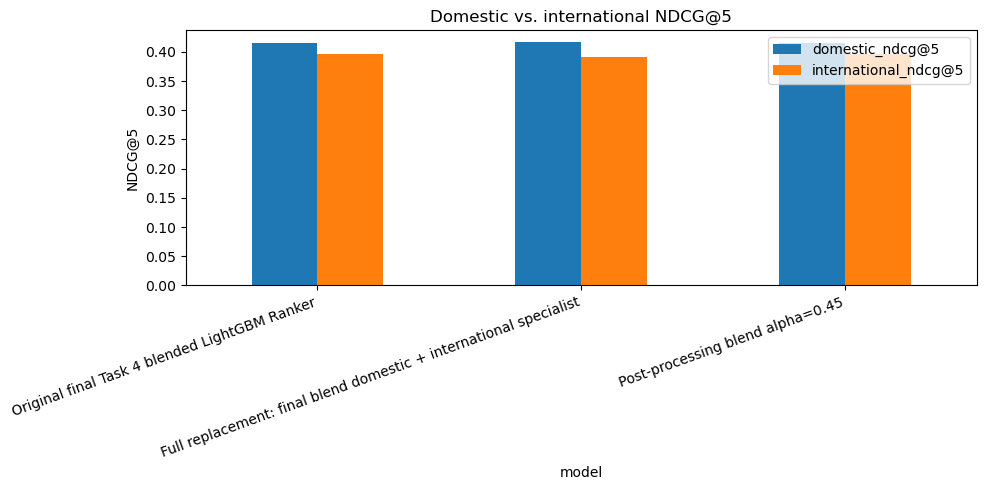

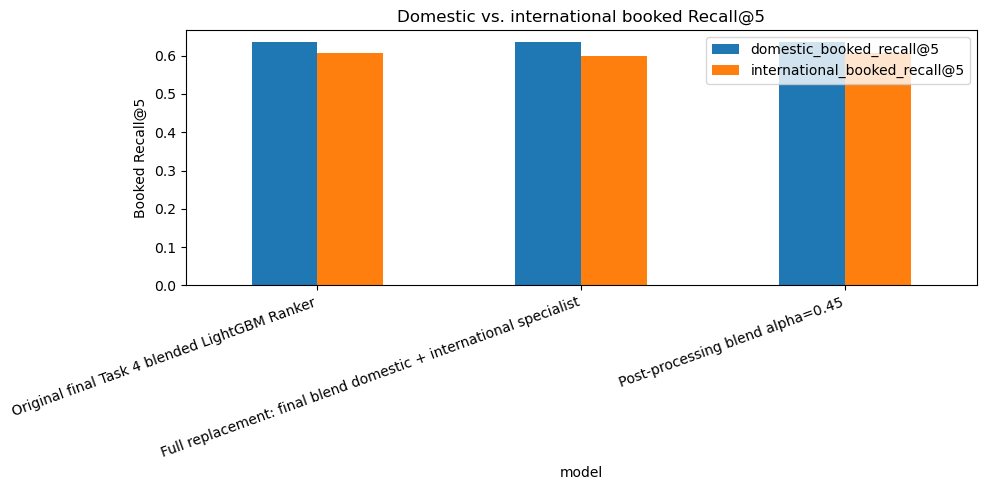

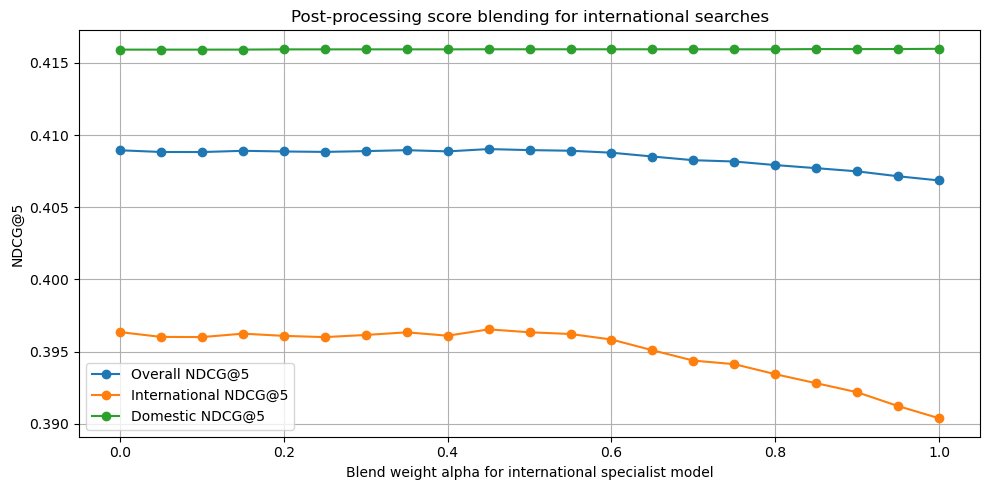

In [20]:
# ---------------------------------------------------
# Cell 20: Plots for report and interpretation
# ---------------------------------------------------

plot_df = comparison.set_index("model")

ax = plot_df[["domestic_ndcg@5", "international_ndcg@5"]].plot(kind="bar", figsize=(10, 5))
plt.title("Domestic vs. international NDCG@5")
plt.ylabel("NDCG@5")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

ax = plot_df[["domestic_booked_recall@5", "international_booked_recall@5"]].plot(kind="bar", figsize=(10, 5))
plt.title("Domestic vs. international booked Recall@5")
plt.ylabel("Booked Recall@5")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(blend_results_df["alpha"], blend_results_df["overall_ndcg@5"], marker="o", label="Overall NDCG@5")
plt.plot(blend_results_df["alpha"], blend_results_df["international_ndcg@5"], marker="o", label="International NDCG@5")
plt.plot(blend_results_df["alpha"], blend_results_df["domestic_ndcg@5"], marker="o", label="Domestic NDCG@5")
plt.xlabel("Blend weight alpha for international specialist model")
plt.ylabel("NDCG@5")
plt.title("Post-processing score blending for international searches")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
# ---------------------------------------------------
# Cell 21: Save result files for report
# ---------------------------------------------------

blend_results_df.to_csv("task5_blending_alpha_results.csv", index=False)
comparison.to_csv("task5_blending_comparison.csv", index=False)
recommended_group_results.to_csv("task5_blending_recommended_group_results.csv", index=False)

try:
    all_mitigations.to_csv("task5_all_domestic_international_mitigations_with_blending.csv", index=False)
except NameError:
    pass

print("Saved Task 5 blending result files.")

Saved Task 5 blending result files.


## How to interpret the result

Use the blended mitigation only if it improves international-search performance without reducing overall NDCG too much.

Good signs:
- `international_ndcg@5` increases compared with the original final Task 4 blend.
- `international_booked_recall@5` increases.
- `international_minus_domestic_ndcg@5` becomes less negative.
- `overall_ndcg@5` stays close to or above the original final Task 4 blend.

If a middle alpha works better than `alpha = 1.0`, that means the original final blend and the international specialist contain complementary information. In the report, describe this as a **post-processing mitigation**, because it adjusts prediction scores after training rather than changing the training data.
